<a href="https://colab.research.google.com/github/LuqmanSyah/sales-inventory-forecasting/blob/main/Peramalan_Stok_%26_Permintaan_(Sales_%26_Inventory_Forecasting).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Download Dataset via Kagglehub

In [2]:
!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path file langsung di session Colab
path = "."
print("Siap! File train.csv sudah ada di direktori utama.")

Siap! File train.csv sudah ada di direktori utama.


Load Data & Cek Struktur

In [3]:
# Load dataset train.csv
df = pd.read_csv(os.path.join(path, "train.csv"))

# Ubah kolom date ke format datetime
df['date'] = pd.to_datetime(df['date'])

# Urutkan data berdasarkan tanggal
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

print("Jumlah baris & kolom:", df.shape)
print("\nInformasi Tipe Data:")
print(df.info())

df.head()

Jumlah baris & kolom: (913000, 4)

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB
None


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


Exploratory Data Analysis (EDA) - Visualisasi Penjualan

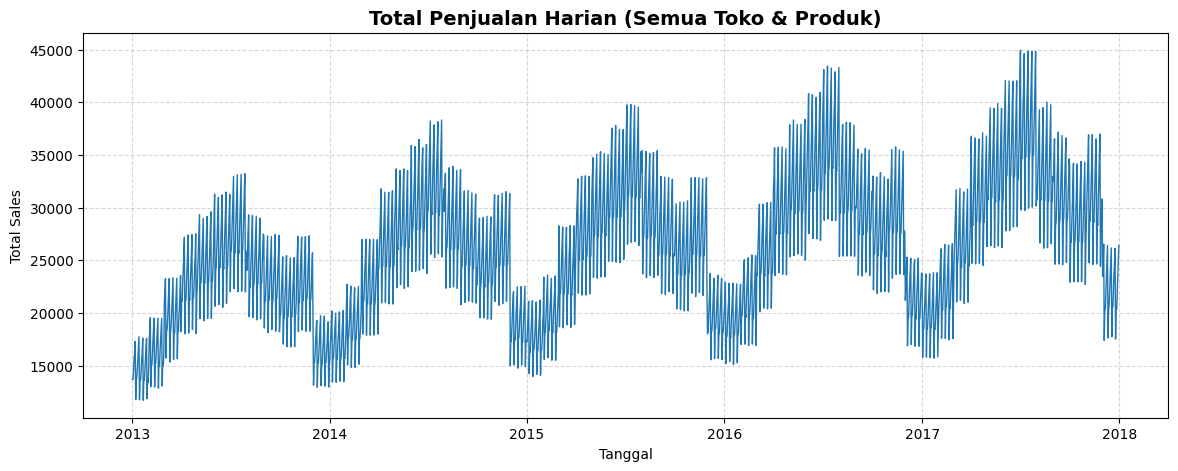

In [4]:
# Agregasi total penjualan harian untuk seluruh toko & produk
daily_sales = df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], color='tab:blue', linewidth=1)
plt.title('Total Penjualan Harian (Semua Toko & Produk)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Feature Engineering (Waktu & Calendar Features)

In [5]:
def create_time_features(df):
    df = df.copy()
    # Kalender dasar
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    return df

df_featured = create_time_features(df)
df_featured.head()

,date,store,item,sales,dayofweek,month,year,dayofmonth,weekofyear,is_weekend
0,2013-01-01,1,1,13,1,1,2013,1,1,0
1,2013-01-02,1,1,11,2,1,2013,2,1,0
2,2013-01-03,1,1,14,3,1,2013,3,1,0
3,2013-01-04,1,1,13,4,1,2013,4,1,0
4,2013-01-05,1,1,10,5,1,2013,5,1,1


Feature Engineering (Lag & Rolling Mean Features)

In [6]:
# Lag Features (Penjualan X hari lalu per toko & barang)
for lag in [1, 7, 14, 30]:
    df_featured[f'sales_lag_{lag}'] = df_featured.groupby(['store', 'item'])['sales'].shift(lag)

# Rolling Mean Features (Rata-rata penjualan 7 & 30 hari terakhir)
df_featured['rolling_mean_7'] = df_featured.groupby(['store', 'item'])['sales_lag_1'].transform(lambda x: x.rolling(window=7).mean())
df_featured['rolling_mean_30'] = df_featured.groupby(['store', 'item'])['sales_lag_1'].transform(lambda x: x.rolling(window=30).mean())

# Hapus baris NaN akibat shifting/lag
df_clean = df_featured.dropna().reset_index(drop=True)

print("Ukuran dataset setelah feature engineering:", df_clean.shape)
df_clean.head()

Ukuran dataset setelah feature engineering: (898000, 16)


,date,store,item,sales,dayofweek,month,year,dayofmonth,weekofyear,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-31,1,1,13,3,1,2013,31,5,0,9.0,8.0,16.0,13.0,10.285714,10.500000
1,2013-02-01,1,1,11,4,2,2013,1,5,0,13.0,14.0,7.0,11.0,11.000000,10.500000
2,2013-02-02,1,1,21,5,2,2013,2,5,1,11.0,12.0,18.0,14.0,10.571429,10.500000
3,2013-02-03,1,1,15,6,2,2013,3,5,1,21.0,12.0,15.0,13.0,11.857143,10.733333
4,2013-02-04,1,1,14,0,2,2013,4,6,0,15.0,11.0,8.0,10.0,12.285714,10.800000


Train / Test Split Berdasarkan Waktu

In [7]:
# Pisahkan data Train (2013-2016) dan Test (2017)
train = df_clean[df_clean['date'] < '2017-01-01']
test = df_clean[df_clean['date'] >= '2017-01-01']

# Tentukan kolom fitur (X) dan target (y)
features = [col for col in df_clean.columns if col not in ['date', 'sales']]
target = 'sales'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Jumlah Data Train: {len(X_train)} baris ({train['date'].min().strftime('%Y-%m-%d')} s/d {train['date'].max().strftime('%Y-%m-%d')})")
print(f"Jumlah Data Test : {len(X_test)} baris ({test['date'].min().strftime('%Y-%m-%d')} s/d {test['date'].max().strftime('%Y-%m-%d')})")
print("Fitur yang digunakan:", features)

Jumlah Data Train: 715500 baris (2013-01-31 s/d 2016-12-31)
Jumlah Data Test : 182500 baris (2017-01-01 s/d 2017-12-31)
Fitur yang digunakan: ['store', 'item', 'dayofweek', 'month', 'year', 'dayofmonth', 'weekofyear', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_30']


Training Model XGBoost Regressor

In [8]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Inisialisasi dan Train Model
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Mulai proses training XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)
print("Training selesai!")

Mulai proses training XGBoost...
[0]	validation_0-rmse:27.11116	validation_1-rmse:31.62023
[100]	validation_0-rmse:7.76539	validation_1-rmse:8.55077
[200]	validation_0-rmse:7.45104	validation_1-rmse:8.11617
[300]	validation_0-rmse:7.36913	validation_1-rmse:8.02118
[400]	validation_0-rmse:7.32348	validation_1-rmse:7.97764
[499]	validation_0-rmse:7.28983	validation_1-rmse:7.95133
Training selesai!


Evaluasi Model (MAE & RMSE)

In [9]:
# Prediksi data test
y_pred = model.predict(X_test)

# Hitung Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Hasil Evaluasi Model pada Data Test (Tahun 2017) ===")
print(f"MAE  (Mean Absolute Error) : {mae:.2f} unit barang")
print(f"RMSE (Root Mean Sq Error)  : {rmse:.2f} unit barang")

=== Hasil Evaluasi Model pada Data Test (Tahun 2017) ===
MAE  (Mean Absolute Error) : 6.12 unit barang
RMSE (Root Mean Sq Error)  : 7.95 unit barang


Feature Importance & Visualisasi Prediksi

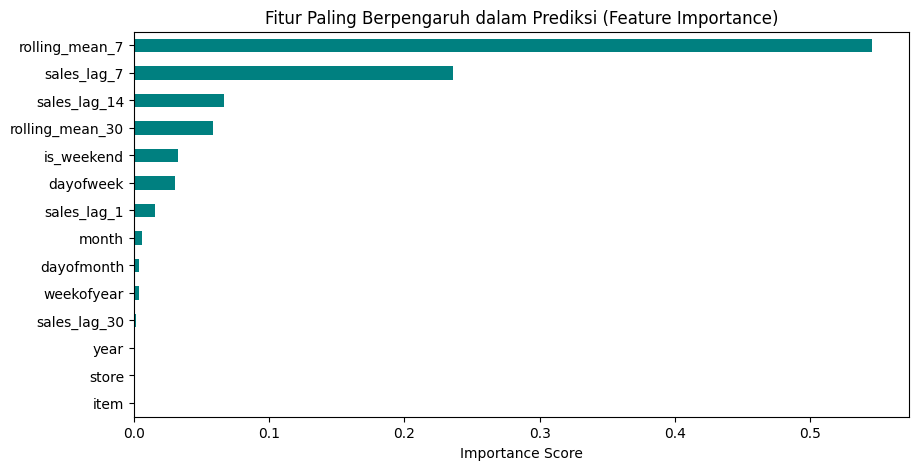

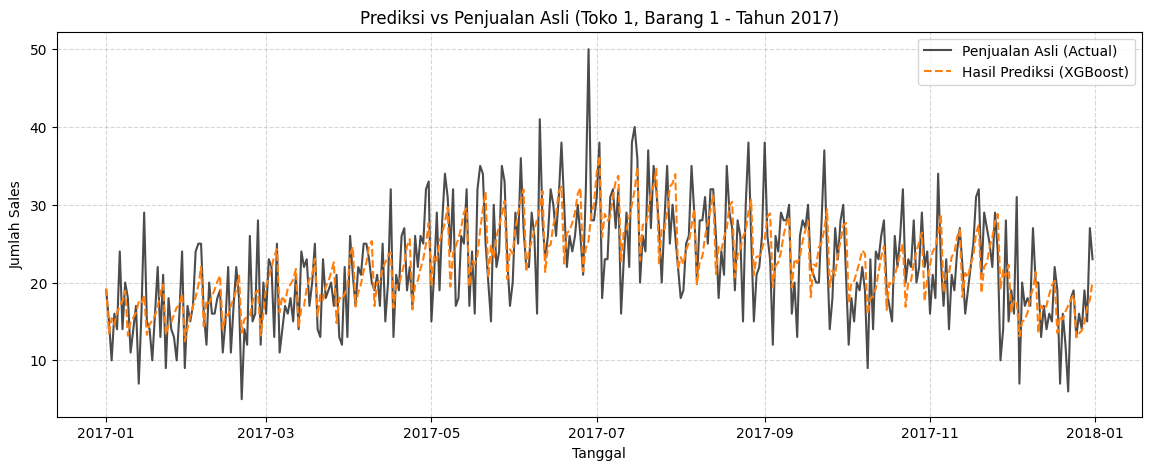

In [10]:
# 1. Plot Feature Importance
plt.figure(figsize=(10, 5))
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Fitur Paling Berpengaruh dalam Prediksi (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

# 2. Plot Prediksi vs Actual (Sampel Toko 1, Item 1 di Tahun 2017)
sample_test = test[(test['store'] == 1) & (test['item'] == 1)].copy()
sample_test['pred_sales'] = model.predict(sample_test[features])

plt.figure(figsize=(14, 5))
plt.plot(sample_test['date'], sample_test['sales'], label='Penjualan Asli (Actual)', color='black', alpha=0.7)
plt.plot(sample_test['date'], sample_test['pred_sales'], label='Hasil Prediksi (XGBoost)', color='tab:orange', linestyle='--')
plt.title('Prediksi vs Penjualan Asli (Toko 1, Barang 1 - Tahun 2017)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Simpan Model XGBoost

In [11]:
import joblib

# Simpan model ke file local
joblib.dump(model, 'xgboost_forecasting_model.pkl')
print("Model berhasil disimpan sebagai 'xgboost_forecasting_model.pkl'!")

Model berhasil disimpan sebagai 'xgboost_forecasting_model.pkl'!


Simulasi Logic Sistem Restock / Safety Stock (Fitur Bisnis)

In [12]:
def check_restock_status(store_id, item_id, current_stock, safety_stock=20):
    # Ambil data 30 hari terakhir dari item tersebut
    item_data = df_clean[(df_clean['store'] == store_id) & (df_clean['item'] == item_id)].tail(7)

    # Prediksi estimasi penjualan 7 hari ke depan
    pred_7_days = model.predict(item_data[features]).sum()

    required_stock = pred_7_days + safety_stock
    needs_reorder = current_stock < required_stock

    print(f"=== LAPORAN STOK: Toko {store_id} | Barang {item_id} ===")
    print(f"Stok Saat Ini            : {current_stock} unit")
    print(f"Estimasi Penjualan 7 Hari: {int(pred_7_days)} unit")
    print(f"Safety Stock Required    : {safety_stock} unit")
    print(f"Total Stok Dibutuhkan    : {int(required_stock)} unit")
    print("--------------------------------------------------")

    if needs_reorder:
        reorder_qty = int(required_stock - current_stock)
        print(f"STATUS: 🚨 PERLU REORDER SEGERA! (Saran Tambahan Stok: +{reorder_qty} unit)")
    else:
        print("STATUS: ✅ STOK AMAN")

# Coba simulasi untuk Toko 1, Barang 1
# Skenario 1: Stok tersisa 100 unit
check_restock_status(store_id=1, item_id=1, current_stock=100)

print("\n")

# Skenario 2: Stok tersisa 250 unit
check_restock_status(store_id=1, item_id=1, current_stock=250)

=== LAPORAN STOK: Toko 1 | Barang 1 ===
Stok Saat Ini            : 100 unit
Estimasi Penjualan 7 Hari: 109 unit
Safety Stock Required    : 20 unit
Total Stok Dibutuhkan    : 129 unit
--------------------------------------------------
STATUS: 🚨 PERLU REORDER SEGERA! (Saran Tambahan Stok: +29 unit)


=== LAPORAN STOK: Toko 1 | Barang 1 ===
Stok Saat Ini            : 250 unit
Estimasi Penjualan 7 Hari: 109 unit
Safety Stock Required    : 20 unit
Total Stok Dibutuhkan    : 129 unit
--------------------------------------------------
STATUS: ✅ STOK AMAN
